In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.widgets import Slider
import time
import json
import warnings
from glob import glob
%matplotlib widget
from tqdm.notebook import tqdm
from scipy.special import iv as mod_bessel #modified bessel function

In [2]:
plt.rcParams["font.family"] = "serif"
cols = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
 '#7f7f7f', '#bcbd22', '#17becf']

In [3]:
#useful functions for getting the system positions at different times for 
def get_pos_at_time(pos_hists, time_hists, sample_time):
    pos_at_time = []
    for run_id in range(len(time_hists)):
        time_exists = np.isclose(time_hists[run_id], np.ones(np.shape(time_hists[run_id]))*sample_time
                                 , rtol = 1e-5, atol = 1e-5)
        id_time = np.where(time_exists == True)[0]
        if np.size(id_time) > 0: 
            pos_at_time.append(pos_hists[run_id][id_time[0]])
    if len(pos_at_time) == 0: 
        print(f"No positions were sampled at that time: {sample_time}")
    return pos_at_time

def normal(x, mu, var): 
    return 1/np.sqrt(2*np.pi*var)*np.exp(-(x-mu)**2/(2*var))

def import_hists(fname):
    '''Imports data from a certain folder with fname, 
    returns pos_hists, time_hists, D_hists, bonds_hists, old_sys_params'''
    if fname[:9] == "run_hist/":
        paths = glob(fname+"/*")
    else:
        paths = glob("run_hist/"+fname+"/*")
    if len(paths) == 0: 
        print(f"no paths found in {fname}")
    pos_hists = []
    time_hists = []
    D_hists = []
    bonds_hists = []
    old_sys_params = None 
    old_num_elems = None 
    old_dim = None
    
    for path in paths: 
        file = open(path)
        jsondict = json.load(file)
        # check systems_params: 
        if old_sys_params != None:
            if old_sys_params != jsondict["System_Parameters"]: 
                for key in jsondict["System_Parameters"].keys():
                    if old_sys_params[key] != jsondict["System_Parameters"][key]:
                        print("Parameter",key,f"is not the same, old value {old_sys_params[key]} "
                              f"new value {jsondict['System_Parameters'][key]}, Filename = {path[-20:]}")
                        
        #check number of elems
        if old_num_elems != None: 
            if old_num_elems != jsondict["Initial_Parameters"]["num_elements"]:
                print(f"Different number of elements , old value {old_num_elems} "
                              f"new value {jsondict['Initial_Parameters']['num_elements']}, Filename = {path[-20:]}")

        #check dimension
        if old_dim != None: 
            if old_dim != np.shape(jsondict['Initial_Parameters']['connectivity'])[0]:
                print(f"Different dimension , old value {old_dim} "
                      f"new value {np.shape(jsondict['Initial_Parameters']['connectivity'])[0]},"
                      f"Filename = {path[-20:]}")

        old_dim = np.shape(jsondict['Initial_Parameters']['connectivity'])[0]
        old_num_elems = jsondict["Initial_Parameters"]["num_elements"]
        old_sys_params = jsondict["System_Parameters"]
        bonds_hists.append(jsondict["Sampled_States"]["bonds_hist"])
        pos_hists.append(jsondict["Sampled_States"]["pos_hist"])
        time_hists.append(jsondict["Sampled_States"]["time_hist"])
        D_hists.append(jsondict["Results"]["diffusion_constant"])
        file.close()
    
    return (pos_hists, time_hists, D_hists, bonds_hists, old_sys_params)
    

In [4]:
def get_diffusion(foldername, ignore_num = 1): 
    '''Inputs: foldername, returns mean_diffusion, std_diffusion, ignores first "ignore_num" values,
    deals dynamically with list input by itself returning a list'''
    if isinstance(foldername, list): 
        list_D_mean = []
        list_dD_mean = []
        for item in foldername: 
            _ , _, D_hists, _, params = import_hists(item)
            D_hists = np.array(D_hists)
            D_hists_mean = np.mean(D_hists[:,ignore_num:], axis = 1)
            D_mean = np.mean(D_hists_mean) 
            dD_mean = np.std(D_hists_mean)/np.sqrt(np.shape(D_hists_mean)[0])
            list_D_mean.append(D_mean)
            list_dD_mean.append(dD_mean)
        return np.array(list_D_mean), np.array(list_dD_mean)
            
    else: 
        _ , _, D_hists, _, params = import_hists(foldername)
        D_hists = np.array(D_hists)
        D_hists_mean = np.mean(D_hists[:,ignore_num:], axis = 1)
        D_mean = np.mean(D_hists_mean) 
        dD_mean = np.std(D_hists_mean)/np.sqrt(np.shape(D_hists_mean)[0])
        return D_mean, dD_mean

### 1 particle Simulation


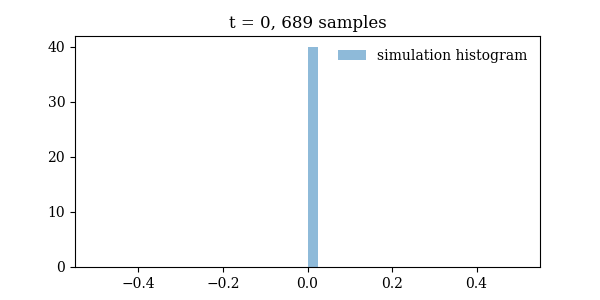

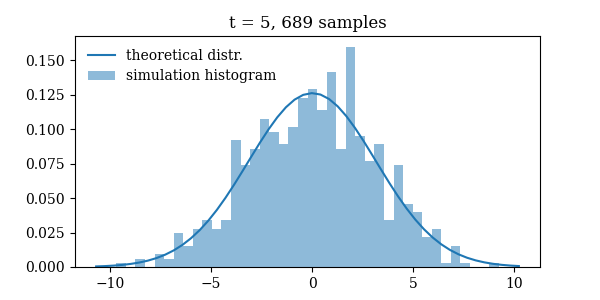

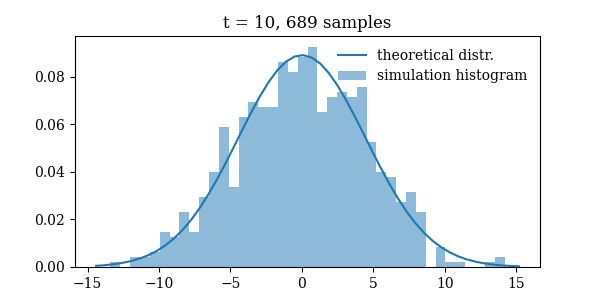

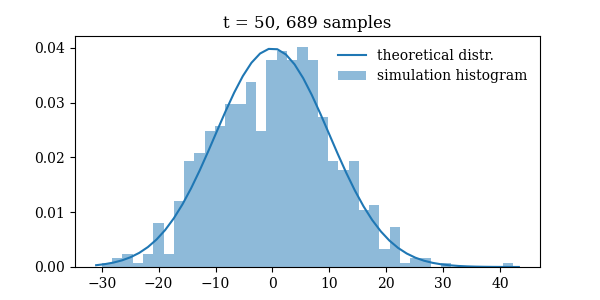

In [5]:
# #checking the 1 particle solution without binding
fname = "1part_1d/no_binding"
pos_hists, time_hists, D_hists, bonds_hists, old_sys_params = import_hists(fname)
times = [0,5,10,50]
plt.close('all') 

for sample_time in times:
    pos_at_time = get_pos_at_time(pos_hists,time_hists,sample_time)
    pos_at_time = np.array(pos_at_time).squeeze() #converts to array and removes unnecessary dimension
    plt.figure(figsize = (6,3))
    plt.title(f"t = {sample_time}, {len(pos_at_time)} samples") 

    N, bins, _ = plt.hist(pos_at_time, density = True, bins = 40, alpha = 0.5, label = "simulation histogram")
    if sample_time != 0: 
        plt.plot(np.linspace(bins[0]-1, bins[-1]+1), normal(np.linspace(bins[0]-1, bins[-1]+1),0,2*sample_time),
                color = '#1f77b4', label = "theoretical distr.")
    plt.legend(frameon = False)
    plt.show()

### 2 particle analysis

Parameter dt is not the same, old value 0.001 new value 0.0001, Filename = 16042024_145258.json
Parameter l0 is not the same, old value [[0.0, 1.0], [1.0, 0.0]] new value 1, Filename = 30032024_142239.json
Parameter dt is not the same, old value 0.0001 new value 0.001, Filename = 30032024_142239.json
time 0.0001 num_runs 879
time 0.002 num_runs 879
time 0.01 num_runs 879


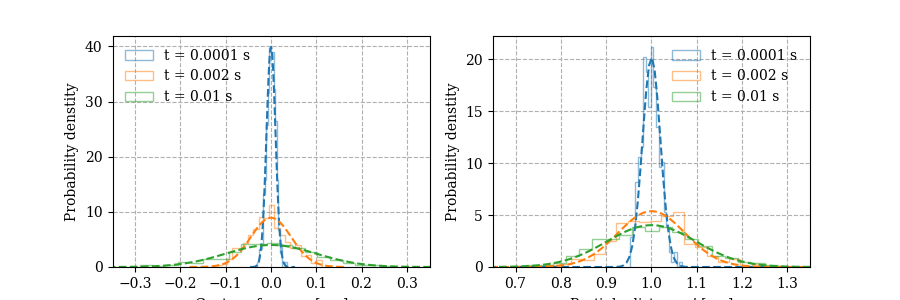

In [16]:
#plotting the results of the 2 element simulation
fname = "2part_1d/no_binding"
pos_hists, time_hists, D_hists, bonds_hists, old_sys_params = import_hists(fname)

#import params: 
params = old_sys_params 
#useful functions and solutions
def pdf_r(r,t): 
    return normal(r, 0, params["kB"]*params["Temp"]/params["gamma"]*t)
    
def pdf_l(l,t): 
    return normal(l, 1, params["kB"]*params["Temp"]/params["k"]*(1-np.exp(-4*params["k"]*t/params["gamma"])))


#plot the r and l evolution
times = [0.0001,0.002, 0.01]
plt.close('all') 
counter = 0 
fig, ax = plt.subplots(ncols = 2)
fig.set_size_inches(9,3)
    
for sample_time in times:
    pos_at_time = get_pos_at_time(pos_hists,time_hists,sample_time)
    print("time",sample_time,"num_runs",len(pos_hists))
    pos_at_time = np.array(pos_at_time).squeeze() #converts to array and removes unnecessary dimension
    
    N, bins, patches = ax[0].hist((pos_at_time[:,0]+pos_at_time[:,1])/2, density = True, bins = 20,
                                 color = cols[counter], histtype = "step", label = f"t = {sample_time} s",alpha = 0.5) #plot com
    if sample_time!=0: 
        ax[0].plot(np.linspace(bins[0]*1.5, bins[-1]*1.5, 100),
                   pdf_r(np.linspace(bins[0]*1.5, bins[-1]*1.5, 100),sample_time), 
                  color = cols[counter], ls = "dashed")
    ax[0].set_xlabel("Center of mass $r$ [$\mu$m]")
    ax[0].set_ylabel("Probability denstity")
        
    N, bins, patches = ax[1].hist((pos_at_time[:,1]-pos_at_time[:,0]), density = True, bins = 20, alpha = 0.5, 
                                 color = cols[counter],histtype = "step", label = f"t = {sample_time} s") #plot distance
    ax[1].set_xlabel("Particle distance $l$ [$\mu$m]")
    ax[1].set_ylabel("Probability denstity")
    if sample_time!=0: 
        ax[1].plot(np.linspace(bins[0]-0.25, bins[-1]+0.25, 100),
                   pdf_l(np.linspace(bins[0]-0.25, bins[-1]+0.25, 100),sample_time),
                  color = cols[counter], ls = "dashed")
    counter += 1
ax[1].grid(ls = "dashed")
ax[0].grid(ls = "dashed")
ax[0].legend(frameon = False)  
ax[1].legend(frameon = False) 
ax[0].set_xlim(-0.35,0.35)
ax[1].set_xlim(0.65,1.35)
plt.savefig("images/2part_1d.pdf", bbox_inches = "tight")
plt.show()    


### Diffusion of Ring Structures

In [17]:
# calculation and comparison of diffusion constant for ringstructure:
fname = "1part_2d/qon0qoff0"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 1)
D100_mean = np.mean(D_mean_hists) 
D100_std = np.std(D_mean_hists)

fname = "1part_2d/qon1qoff1"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 1)
D111_mean = np.mean(D_mean_hists) 
D111_std = np.std(D_mean_hists)

fname = "2part_2d/qon0qoff0"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 1)
D200_mean = np.mean(D_mean_hists) 
D200_std = np.std(D_mean_hists)

fname = "2part_2d/qon1qoff1"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 1)
D211_mean = np.mean(D_mean_hists) 
D211_std = np.std(D_mean_hists)

fname = "3part_2d/qon0qoff0"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 1)
D300_mean = np.mean(D_mean_hists) 
D300_std = np.std(D_mean_hists)

fname = "3part_2d/qon1qoff1"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 1)
D311_mean = np.mean(D_mean_hists) 
D311_std = np.std(D_mean_hists)

fname = "4part_2d/qon0qoff0"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 1)
D400_mean = np.mean(D_mean_hists) 
D400_std = np.std(D_mean_hists)

fname = "4part_2d/qon1qoff1"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 1)
D411_mean = np.mean(D_mean_hists) 
D411_std = np.std(D_mean_hists)

fname = "5part_2d/qon0qoff0"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 1)
D500_mean = np.mean(D_mean_hists) 
D500_std = np.std(D_mean_hists)

Parameter l0 is not the same, old value 1 new value [[0.0, 1.0], [1.0, 0.0]], Filename = 16042024_142639.json


C:\Users\frede\anaconda3\lib\site-packages\numpy\core\_asarray.py:171: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order, subok=True)


AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
#plotting the result
nr_particles_00 = np.arange(1,6)
D00_means = [D100_mean, D200_mean, D300_mean, D400_mean, D500_mean]
D00_stds = [D100_std, D200_std, D300_std, D400_std, D500_std]

nr_particles_11 = np.arange(1,5)
D11_means = [D111_mean, D211_mean, D311_mean, D411_mean]
D11_stds = [D111_std, D211_std, D311_std, D411_std]

#theoretical values
nr_theo_11 = [1]
nr_theo_00 = [1,2]

cols = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
 '#7f7f7f', '#bcbd22', '#17becf']
plt.close("all")
plt.figure()
plt.errorbar(nr_particles_00, D00_means, yerr = D00_stds, ls = "None",
             marker = "x", label ="unbound simulation", color = cols[0])
plt.scatter(nr_theo_00, [1,0.5], facecolors='none', edgecolors=cols[0], label = "theoretical values, unbound")

plt.errorbar(nr_particles_11, D11_means, yerr = D11_stds, ls = "None",
             marker = "x", label ="bound simulation, qoff = 1, qon = 1", color = cols[1])
plt.scatter(nr_theo_11, [0.5], facecolors='none', edgecolors=cols[1],
            label = "theoretical values, bound qoff 1, qon 1")

plt.grid(ls = "dashed")
plt.legend()
plt.xlabel("Number of elements")
plt.ylabel("Diffusion constant")
plt.show()

In [18]:
# calculation and comparison of diffusion constant for linear (but with weird initial condition):( but on 0 axis)
fname = "1part_2d/qon0qoff0"
pos_hists, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 0)
D100_mean = np.mean(D_mean_hists[1:]) 
D100_std = np.std(D_mean_hists[1:])

fname = "1part_2d/qon1qoff1"
pos_hists, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 0)
D111_mean = np.mean(D_mean_hists[1:]) 
D111_std = np.std(D_mean_hists[1:])

fname = "2part_2d/qon0qoff0"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 0)
D200_mean = np.mean(D_mean_hists)
D200_std = np.std(D_mean_hists)

fname = "2part_2d/qon1qoff1"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 0)
D211_mean = np.mean(D_mean_hists) 
D211_std = np.std(D_mean_hists)

fname = "3part_2d/qon0qoff0"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 0)
D300_mean = np.mean(D_mean_hists) 
D300_std = np.std(D_mean_hists)

fname = "3part_2d/qon1qoff1"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 0)
D311_mean = np.mean(D_mean_hists) 
D311_std = np.std(D_mean_hists)

fname = "4part_2d/qon0qoff0"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 0)
D400_mean = np.mean(D_mean_hists) 
D400_std = np.std(D_mean_hists)

fname = "4part_2d/qon1qoff1"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 0)
D411_mean = np.mean(D_mean_hists) 
D411_std = np.std(D_mean_hists)

fname = "5part_2d/qon0qoff0"
pos_hist, time_hists, D_hists, bonds_hists, params = import_hists(fname)
D_mean_hists = np.mean(D_hists, axis = 0)
D500_mean = np.mean(D_mean_hists) 
D500_std = np.std(D_mean_hists)

Parameter l0 is not the same, old value 1 new value [[0.0, 1.0], [1.0, 0.0]], Filename = 16042024_142639.json


In [19]:
#importing also ring and fully connected for

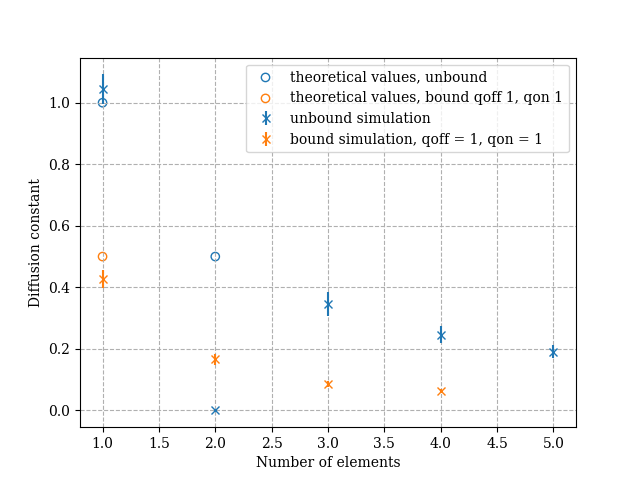

In [20]:
#plotting the result
nr_particles_00 = np.arange(1,6)
D00_means = [D100_mean, D200_mean, D300_mean, D400_mean, D500_mean]
D00_stds = [D100_std, D200_std, D300_std, D400_std, D500_std]

nr_particles_11 = np.arange(1,5)
D11_means = [D111_mean, D211_mean, D311_mean, D411_mean]
D11_stds = [D111_std, D211_std, D311_std, D411_std]

#theoretical values
nr_theo_11 = [1]
nr_theo_00 = [1,2]

cols = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
 '#7f7f7f', '#bcbd22', '#17becf']
plt.close("all")
plt.figure()
plt.errorbar(nr_particles_00, D00_means, yerr = D00_stds, ls = "None",
             marker = "x", label ="unbound simulation", color = cols[0])
plt.scatter(nr_theo_00, [1,0.5], facecolors='none', edgecolors=cols[0], label = "theoretical values, unbound")

plt.errorbar(nr_particles_11, D11_means, yerr = D11_stds, ls = "None",
             marker = "x", label ="bound simulation, qoff = 1, qon = 1", color = cols[1])
plt.scatter(nr_theo_11, [0.5], facecolors='none', edgecolors=cols[1],
            label = "theoretical values, bound qoff 1, qon 1")

plt.grid(ls = "dashed")
plt.legend()
plt.xlabel("Number of elements")
plt.ylabel("Diffusion constant")
plt.show()

### Analyzing Ring, Linear and Fully Connected Simulations

In [5]:
foldernames_f11 = glob("run_hist/fully_connected/*/qon1qoff1")  #f11 short for fully connected qon 1 qoff 1
num_elems_f11 = np.array([10,3,4,5,6,7,8,9])
list_D_mean_f11, list_dD_mean_f11 = get_diffusion(foldernames_f11)

foldernames_r11 = glob("run_hist/rings/*/qon1qoff1")  #r11 short for rings qon 1 qoff 1
num_elems_r11 = np.array([10,3,4,5,6,7,8,9])
list_D_mean_r11, list_dD_mean_r11 = get_diffusion(foldernames_r11)

foldernames_f_01_1 = glob("run_hist/fully_connected/*/qon0.1qoff1")
num_elems_f_01_1 = np.array([10,3,4,5,6,7,8,9])
list_D_mean_f_01_1, list_dD_mean_f_01_1 = get_diffusion(foldernames_f_01_1)

foldernames_r_01_1 = glob("run_hist/rings/*/qon0.1qoff1")
num_elems_r_01_1 = np.array([10,3,4,5,6,7,8,9])
list_D_mean_r_01_1, list_dD_mean_r_01_1 = get_diffusion(foldernames_r_01_1)

foldernames_r_0_0 = glob("run_hist/rings/*/qon0qoff0")
num_elems_r_0_0 = np.array([10,3,4,5,6,7,8,9])
list_D_mean_r_0_0, list_dD_mean_r_0_0 = get_diffusion(foldernames_r_0_0)

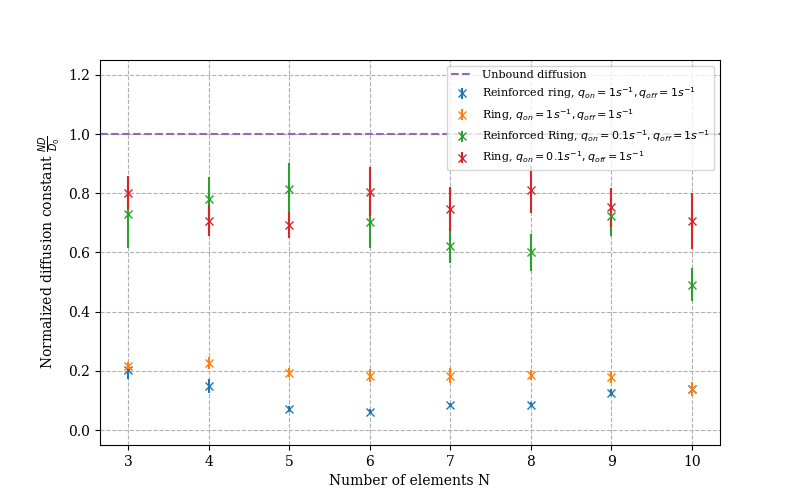

In [8]:
cols = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
 '#7f7f7f', '#bcbd22', '#17becf']
plt.close("all")


plt.figure(figsize = (8,5))
plt.errorbar(num_elems_f11, list_D_mean_f11*num_elems_f11, yerr = list_dD_mean_f11*num_elems_f11,
             ls = "None", marker = "x", label ="Reinforced ring, $q_{on} = 1 s^{-1}, q_{off} = 1 s^{-1}$")

plt.errorbar(num_elems_r11, list_D_mean_r11*num_elems_r11, yerr = list_dD_mean_r11*num_elems_r11,
             ls = "None", marker = "x", label ="Ring, $q_{on} = 1 s^{-1}, q_{off} = 1 s^{-1}$")

plt.errorbar(num_elems_f_01_1, list_D_mean_f_01_1*num_elems_f_01_1, yerr = list_dD_mean_f_01_1*num_elems_f_01_1,
             ls = "None", marker = "x", label ="Reinforced Ring, $q_{on} = 0.1 s^{-1}, q_{off} = 1 s^{-1}$")

plt.errorbar(num_elems_r_01_1, list_D_mean_r_01_1*num_elems_r_01_1, yerr = list_dD_mean_r_01_1*num_elems_r_01_1,
             ls = "None", marker = "x", label ="Ring, $q_{on} = 0.1 s^{-1}, q_{off} = 1 s^{-1}$")

# plt.errorbar(num_elems_r_0_0, list_D_mean_r_0_0*num_elems_r_0_0, yerr = list_dD_mean_r_0_0*num_elems_r_0_0,
#              ls = "None", marker = "x", label ="Ring, $q_{on} = 0, q_{off} = 0$")

#plt.errorbar(np.arange(2,11),np.ones(9), marker = "x", label = "Unbound diffusion", ls = "None") 
plt.axhline(1, label = "Unbound diffusion", ls = "dashed", color = cols[4])
plt.xlabel("Number of elements N")
plt.xticks([3,4,5,6,7,8,9,10])
plt.ylabel("Normalized diffusion constant $\\frac{ND}{D_0}$")
plt.legend(loc = "upper right",prop={'size': 8})
plt.ylim(-0.05, 1.25)
plt.grid(ls = "dashed")
plt.savefig("images/diffusion_sim.pdf")
plt.show()

### Analyzing approximation for 2part1d dependence on k 

In [27]:
foldernames_k = glob("run_hist/2part_1d_k/*")
#list_D_mean_k, list_dD_mean_k = get_diffusion(foldernames_k)
list_k = []
for foldername in foldernames_k: 
    example_file = glob(foldername+"/*")[0]
    file = open(example_file)
    jsondict = json.load(file)
    print(jsondict["System_Parameters"]["k"])
    file.close()
    

PermissionError: [Errno 13] Permission denied: 'run_hist/2part_1d_k\\k100\\k10.0'

In [ ]:
plt.figure(figsize = (8,5))
plt.errorbar(num_elems_f11, list_D_mean_f11*num_elems_f11, yerr = list_dD_mean_f11*num_elems_f11,
             ls = "None", marker = "x", label ="Reinforced ring, $q_{on} = 1, q_{off} = 1$")